# 📁 File 02.Descriptive_Statistics_and_Basic_Deals_Analysis

## 📥 1. Loading the Cleaned Deals Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

deals_df = pd.read_excel("Deals (Result).xlsx")

## #️⃣ 2. Calculating Correct Revenue

In [3]:
def calc_revenue(row):
    # Revenue only for Payment Done
    if row["Stage"] != "Payment Done":
        return 0

    # Revenue only for MAIN_PRODUCTS
    if row["Product"] not in ["Digital Marketing", "UX/UI Design", "Web Developer"]:
        return 0

    initial = row["Initial Amount Paid"]
    offer = row["Offer Total Amount"]
    cd = row["Course duration"]
    ms = row["Months of study"]

    # no Initial → no revenue
    if pd.isna(initial):
        return 0

    # no Offer → revenue = Initial
    if pd.isna(offer):
        return initial

    # no duration → revenue = Initial
    if pd.isna(cd) or cd <= 1:
        return initial

    # no months → revenue = Initial
    if pd.isna(ms) or ms <= 1:
        return initial

    # monthly payment
    monthly_payment = (offer - initial) / (cd - 1)

    # actual revenue
    revenue = initial + monthly_payment * (ms - 1)

    # revenue cannot exceed Offer
    return min(revenue, offer)

deals_df["Revenue"] = deals_df.apply(calc_revenue, axis=1)
deals_df["Revenue"] = deals_df.apply(calc_revenue, axis=1)

# AOV — average revenue per month of study
deals_df["AOV"] = deals_df["Revenue"] / deals_df["Months of study"].replace(0, 1)

# Successful deal flag
deals_df["Is_won"] = deals_df["Stage"] == "Payment Done"

 ✔ Revenue is aligned with business logic — reflects real income considering payment type and actual months of study.

## #️⃣ 📊 3. Descriptive Statistics for Numerical Fields

### 🔢 Numerical Columns for Analysis

In [4]:
numeric_cols = [
    "Initial Amount Paid",
    "Offer Total Amount",
    "Revenue",
    "AOV",
    "SLA Seconds",
    "Course duration",
    "Months of study",
    "Duration_days"
]

### 📈 Basic Statistics

In [5]:
deals_df["Duration_days"] = (
    deals_df["Closing Date"] - deals_df["Created Date"]
).dt.days

desc_stats = deals_df[numeric_cols].describe().T
desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max
Initial Amount Paid,4149.0,919.96,1340.64,0.0,300.0,1000.0,1000.0,11000.0
Offer Total Amount,4165.0,7169.25,4633.00,0.0,3500.0,11000.0,11000.0,11500.0
Revenue,21595.0,163.90,1005.40,0.0,0.0,0.0,0.0,11500.0
AOV,840.0,859.23,780.78,0.0,363.0,1000.0,1000.0,11000.0
SLA Seconds,15533.0,115826.22,737252.64,3.0,4380.0,19894.0,56318.0,26908464.0
Course duration,3587.0,10.20,1.83,6.0,11.0,11.0,11.0,11.0
Months of study,840.0,5.44,2.92,0.0,3.0,5.0,8.0,11.0
Duration_days,14645.0,14.88,31.80,-357.0,1.0,3.0,12.0,335.0


### 📉 Extended Statistics

In [6]:
extended_stats = deals_df[numeric_cols].agg(["mean", "median", "min", "max"]).round(2)
extended_stats

,Initial Amount Paid,Offer Total Amount,Revenue,AOV,SLA Seconds,Course duration,Months of study,Duration_days
mean,919.96,7169.25,163.9,859.23,115826.22,10.2,5.44,14.88
median,1000.00,11000.00,0.0,1000.00,19894.00,11.0,5.00,3.00
min,0.00,0.00,0.0,0.00,3.00,6.0,0.00,-357.00
max,11000.00,11500.00,11500.0,11000.00,26908464.00,11.0,11.00,335.00


### #️⃣ 📊 Key Insights
 - Prepayments are stable, but many deals have zero amounts or very low payments.

 - Product pricing is skewed: some premium deals exist, but many are cheap or incorrectly recorded.

 - Actual revenue (Revenue) shows that most clients pay only part of the full price.

 - SLA is highly unstable: median is 5.6 hours, but mean exceeds 30 hours → leads wait too long.

 - Deal duration: median 3 days, but some deals last up to 335 days → managers forget to close deals.

 - Course duration is standardized, but student engagement varies from 0 to 11 months.

## #️⃣ 🏷 4. Categorical Fields Analysis

### 📦 Categorical Fields

In [7]:
for col in ["Quality", "Stage", "Source", "Product", "Education Type", "Payment Type"]:
    deals_df[col] = deals_df[col].fillna("Unknown")

for col in ["Quality", "Stage", "Source", "Product", "Education Type", "Payment Type"]:
    print(f"\n=== {col} ===")
    print(deals_df[col].value_counts())


=== Quality ===
Quality
E - Non Qualified    7634
D - Non Target       6248
C - Low              3459
Unknown              2255
B - Medium           1564
A - High              432
F                       3
Name: count, dtype: int64

=== Stage ===
Stage
Lost                         15743
Call Delayed                  2248
Registered on Webinar         2072
Payment Done                   858
Waiting For Payment            325
Qualificated                   128
Registered on Offline Day      100
Need to Call - Sales            33
Need To Call                    31
Test Sent                       25
Need a consultation             23
New Lead                         6
Unknown                          2
Free Education                   1
Name: count, dtype: int64

=== Source ===
Source
Facebook Ads      4850
Google Ads        4226
Organic           2590
Tiktok Ads        2051
SMM               1730
Youtube Ads       1657
CRM               1656
Bloggers          1089
Telegram posts    1001


### Pie Chart Function

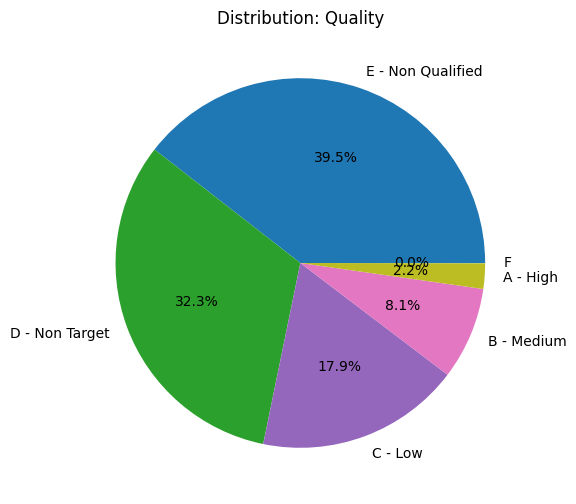

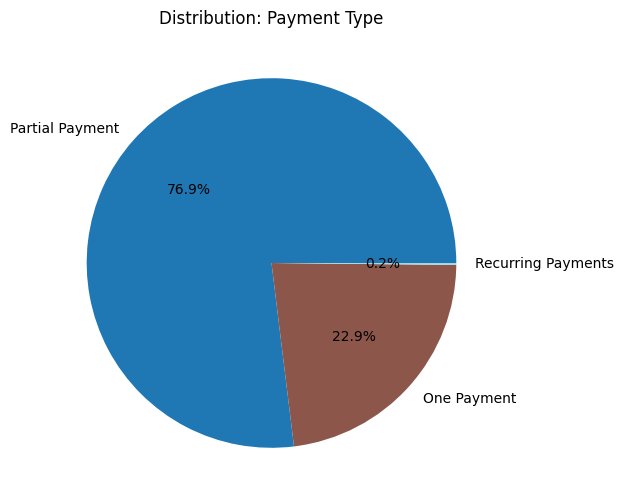

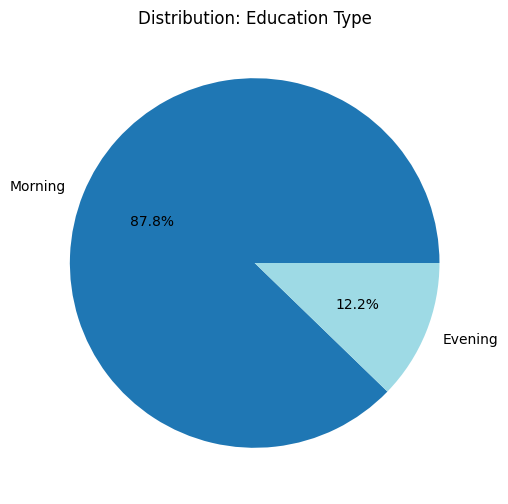

In [8]:
def plot_pie(col):
    plt.figure(figsize=(6,6))

    data = (
        deals_df[col]
        .replace("#REF!", np.nan)
        .replace("Unknown", np.nan)
        .dropna()
    )

    data.value_counts().plot.pie(
        autopct="%1.1f%%",
        cmap="tab20"
    )

    plt.title(f"Distribution: {col}")
    plt.ylabel("")
    plt.show()

plot_pie("Quality")
plot_pie("Payment Type")
plot_pie("Education Type")

### #️⃣ 📊 Insights from Categorical Fields
 - 🎯 Quality — lead quality is low: most leads are low‑grade (E + D = 13,882), 62% of all leads.

 - 🔄 Stage — sales funnel is broken:

     - Lost = 15,743 deals,

     - Payment Done = 858 (extremely low conversion),

     - Call Delayed = 2,248 (leads wait too long).

 - Lead sources are uneven: Google Ads (4,226) and Facebook Ads (4,850) generate almost 40% of all traffic.

 - CRM is poorly filled: Unknown = 17,440 records (~78%).

 - Analytics and unit economics are distorted due to missing key fields.

 - Sales team is overloaded with low‑quality traffic; marketing does not reach the target audience.

## #️⃣ 📆 5. Time Series Analysis

### 📈 Deal Creation Dynamics by Day and Month

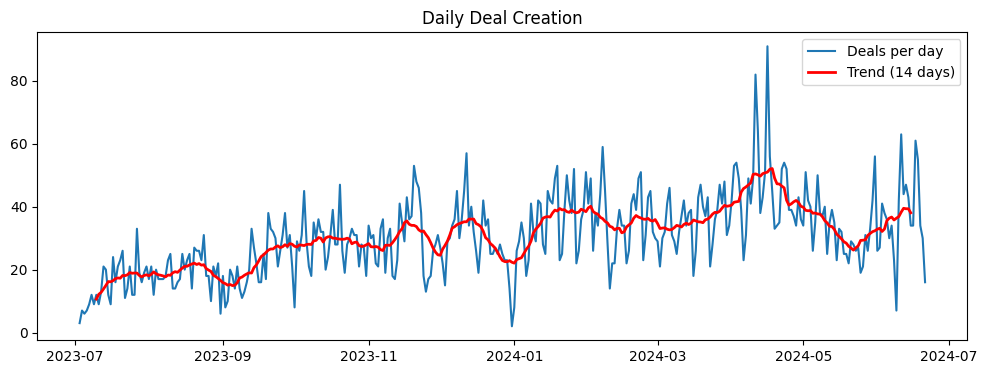

In [9]:
# Daily deal dynamics
deals_by_day = deals_df.groupby("Created Date")["Id"].nunique()

plt.figure(figsize=(12, 4))
plt.plot(deals_by_day.index, deals_by_day.values, label="Deals per day")

trend_day = deals_by_day.rolling(window=14, center=True).mean()
plt.plot(trend_day.index, trend_day.values, color="red", linewidth=2, label="Trend (14 days)")

plt.title("Daily Deal Creation")
plt.legend()
plt.show()

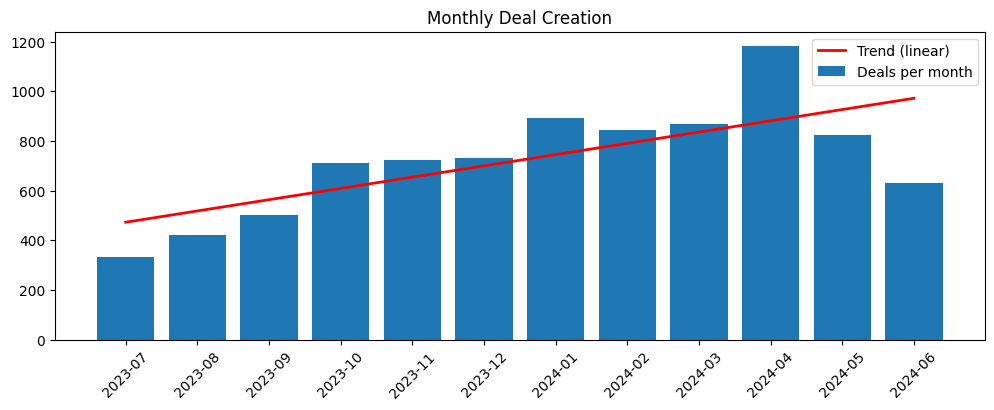

In [10]:
# Monthly deal dynamics
deals_df["month"] = deals_df["Created Date"].dt.to_period("M")
deals_by_month = deals_df.groupby("month")["Id"].nunique()

plt.figure(figsize=(12, 4))
plt.bar(deals_by_month.index.astype(str), deals_by_month.values, label="Deals per month")

x = np.arange(len(deals_by_month))
y = deals_by_month.values
coef = np.polyfit(x, y, 1)
trend_month = np.poly1d(coef)(x)

plt.plot(deals_by_month.index.astype(str), trend_month, color="red", linewidth=2, label="Trend (linear)")

plt.title("Monthly Deal Creation")
plt.xticks(rotation=45)
plt.legend()
plt.show()

### 🔍📊 Key Insights
 ✔ Demand shows clear seasonality: weak summer, strong autumn/winter/spring.
 
 ✔ Peaks align with ad campaigns, webinars, and promotions.
 
 ✔ Lead flow is unstable — sales team works in waves.
 
 ✔ There are periods with almost no leads → lost opportunities.
 
 ✔ Overall trend grows until spring 2024, then declines.
 
 ✔ Business needs stable marketing campaigns and balanced budget allocation.

## #️⃣ ⏳ 6. Deal Duration Analysis

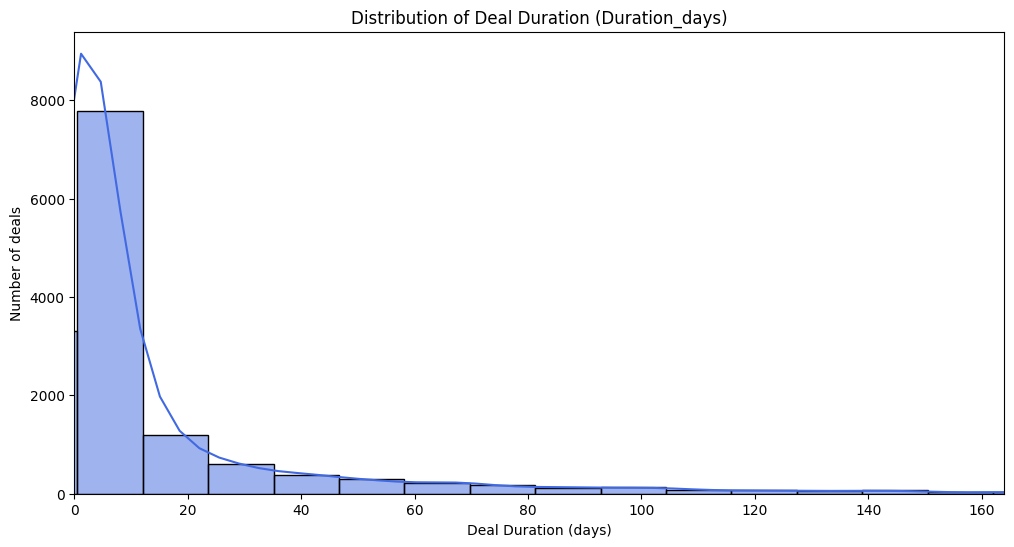

In [11]:
duration_stats = deals_df[deals_df["Duration_days"] >= 0]["Duration_days"].describe().round(2)
duration_stats

plt.figure(figsize=(12,6))
sns.histplot(deals_df["Duration_days"], bins=60, kde=True, color="royalblue")
plt.title("Distribution of Deal Duration (Duration_days)")
plt.xlabel("Deal Duration (days)")
plt.ylabel("Number of deals")
plt.xlim(0, deals_df["Duration_days"].quantile(0.99))
plt.show()

### 🔍 Insights
 ✔ Typical deal duration — 4 days.
 
 ✔ Normal range — 1–12 days.
 
 ✔ Mean is much higher than median → long tail of delayed deals.
 
 ✔ Outliers up to 335 days → forgotten or incorrect records.
 
 ✔ Deals with 0 days — hottest leads.
 
 ✔ Huge variance (std ≈ 31.5) → managers work inconsistently.
 
 ✔ SLA standardization and quality control are required.

## #️⃣ 📞 7. Relationship Between Deals and Number of Calls

### 📥 Loading Calls

In [12]:
calls_df = pd.read_excel("Calls (Result).xlsx")

### 🔢 Number of Calls per Contact

In [13]:
calls_per_contact = (
    calls_df.groupby("CONTACTID")["Id"]
    .count()
    .rename("Calls_count")
)

### 🔗 Merge into Deals

In [14]:
deals_df = deals_df.merge(
    calls_per_contact,
    left_on="Contact Name",
    right_on="CONTACTID",
    how="left"
)

deals_df["Calls_count"] = deals_df["Calls_count"].fillna(0).astype(int)

### 📊 Call Statistics

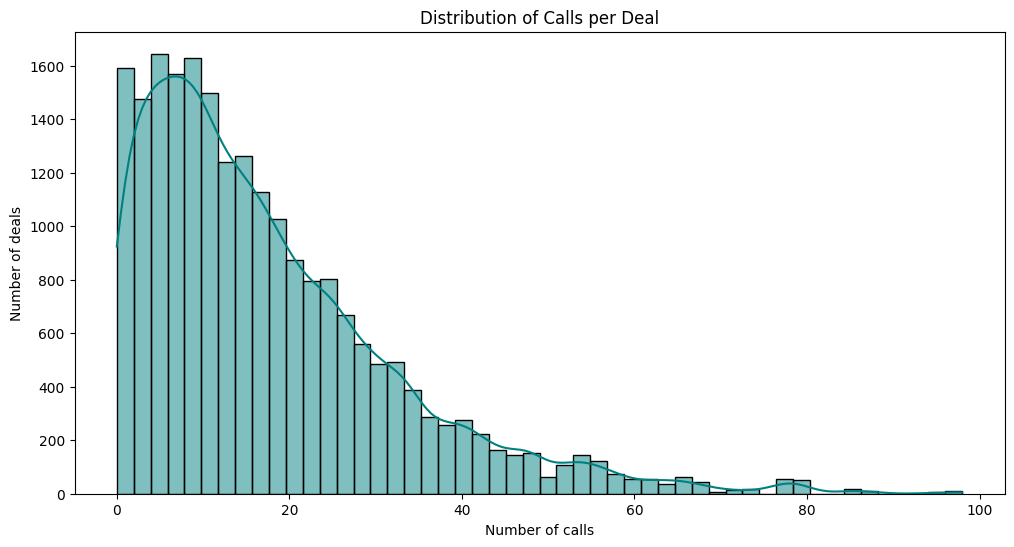

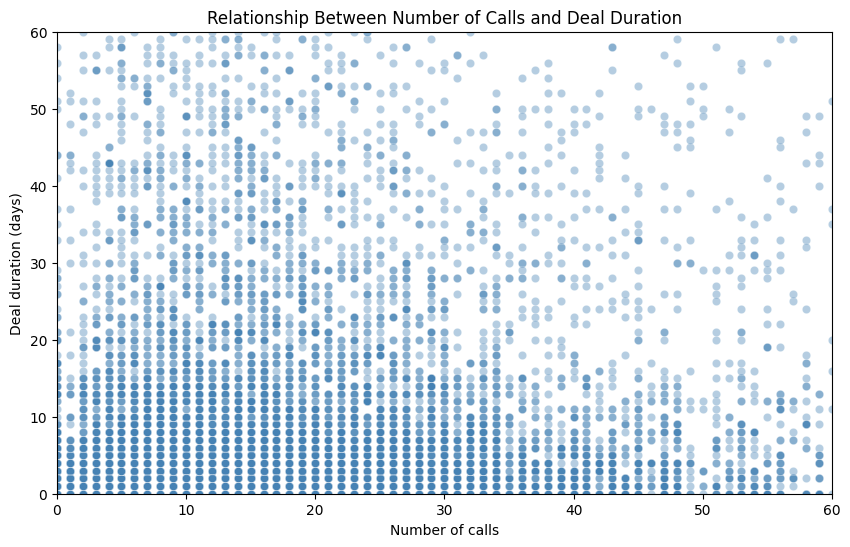

In [15]:
deals_df["Calls_count"].describe().round(2)

plt.figure(figsize=(12,6))
sns.histplot(deals_df["Calls_count"], bins=50, kde=True, color="teal")
plt.title("Distribution of Calls per Deal")
plt.xlabel("Number of calls")
plt.ylabel("Number of deals")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=deals_df["Calls_count"],
    y=deals_df["Duration_days"],
    alpha=0.4,
    color="steelblue"
)

plt.title("Relationship Between Number of Calls and Deal Duration")
plt.xlabel("Number of calls")
plt.ylabel("Deal duration (days)")

plt.xlim(0, 60)
plt.ylim(0, 60)

plt.show()

### 🔍 Insights
 ✔ Typical deal requires ~14 calls (half of all deals).  
 ✔ Normal activity range — 7–24 calls.  
 ✔ Deals with 0 calls → hottest leads.  
 ✔ Extremes up to 113 calls → anomalies or over‑negotiation.  
 ✔ Huge variance (std ≈ 15) → inconsistent manager performance.  

## #️⃣ 📐 8. Descriptive Statistics of Key Metrics

In [16]:
num_cols = ["Offer Total Amount", "Duration_days", "Calls_count"]

num_stats = deals_df[num_cols].describe().round(2)
median_vals = deals_df[num_cols].median().round(2)
mode_vals = deals_df[num_cols].mode().iloc[0].round(2)
range_vals = deals_df[num_cols].max() - deals_df[num_cols].min().round(2)

num_stats, median_vals, mode_vals, range_vals

(       Offer Total Amount  Duration_days  Calls_count
 count             4165.00       14645.00     21595.00
 mean              7169.25          14.88        17.47
 std               4633.00          31.80        15.00
 min                  0.00        -357.00         0.00
 25%               3500.00           1.00         6.00
 50%              11000.00           3.00        14.00
 75%              11000.00          12.00        25.00
 max              11500.00         335.00        98.00,
 Offer Total Amount    11000.0
 Duration_days             3.0
 Calls_count              14.0
 dtype: float64,
 Offer Total Amount    11000.0
 Duration_days             0.0
 Calls_count               0.0
 Name: 0, dtype: float64,
 Offer Total Amount    11500.0
 Duration_days           692.0
 Calls_count              98.0
 dtype: float64)

### 🔍 Insights
 ✔ Product pricing is skewed downward due to cheap deals, although main products are expensive.  
 ✔ Deal duration: typical 3 days, but long tail up to 335 days → forgotten deals.  
 ✔ Calls: median 14, extremes up to 113 → inconsistent manager performance.  
 ✔ All three metrics show high variability and anomalies → unstable sales processes and CRM issues.

## #️⃣ 🕒 9. Deal Duration by Stage

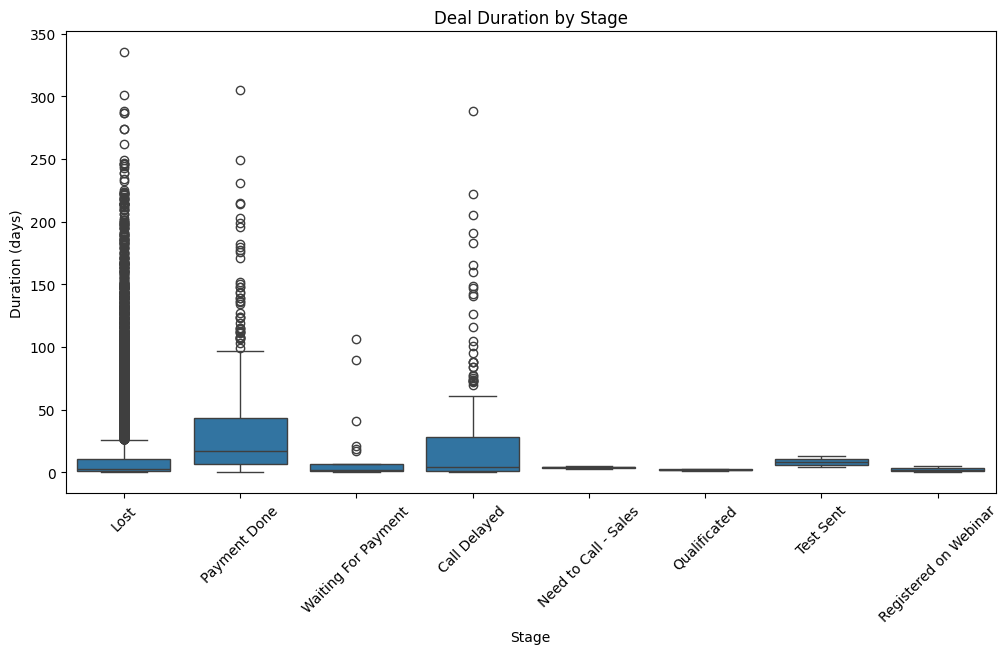

In [17]:
median_by_stage = (
    deals_df.groupby("Stage")["Duration_days"]
    .median()
    .sort_values()
)
median_by_stage

plt.figure(figsize=(12, 6))
filtered_df = deals_df[deals_df["Duration_days"] >= 0]

sns.boxplot(data=filtered_df, x="Stage", y="Duration_days")
plt.xticks(rotation=45)
plt.title("Deal Duration by Stage")
plt.xlabel("Stage")
plt.ylabel("Duration (days)")
plt.show()

### 🔍 📌 Summary
 ✔ Fast stages: Webinar, Waiting For Payment, Qualificated — median 2 days, stable.  
 ✔ Medium stages: Lost, Call Delayed, Need to Call — median 3–4 days, large variance → leads often lost.  
 ✔ Most unstable stage: Payment Done — median 17 days, huge variance → long path to payment.
 ✔ New Lead — technical stage, does not affect duration.  
 ✔ Funnel bottlenecks: Call Delayed → Lost → Payment Done — main points where business loses leads and revenue.

## #️⃣ ⏱ 10. SLA Analysis

In [18]:
sla_stats = deals_df["SLA Seconds"].describe()
sla_stats_rounded = sla_stats.round(2)

sla_converted = pd.DataFrame({
    "seconds": sla_stats_rounded,
    "minutes": (sla_stats_rounded / 60).round(2),
    "hours": (sla_stats_rounded / 3600).round(2)
})

sla_converted

,seconds,minutes,hours
count,15533.00,258.88,4.31
mean,115826.22,1930.44,32.17
std,737252.64,12287.54,204.79
min,3.00,0.05,0.00
25%,4380.00,73.00,1.22
50%,19894.00,331.57,5.53
75%,56318.00,938.63,15.64
max,26908464.00,448474.40,7474.57


### 🔍 #️⃣ Key Insights
 ✔ Typical SLA ≈ 5–6 hours, but mean exceeds 30 hours.  
 ✔ Fast responses are rare; slow responses are common.  
 ✔ 75% of leads receive a response within 15.7 hours.  
 ✔ High SLA → lost leads and lower conversion.  
 ✔ Extreme SLA values (up to 311 days) → errors or forgotten leads.  
 ✔ Managers work inconsistently — SLA requires strict standardization.  

### #️⃣ 💾 11. Saving

In [19]:
deals_df.to_excel("Deals_clean.xlsx", index=False)

## #️⃣ 🚀 Final Conclusion
 The business is growing, but sales processes and CRM performance are inconsistent.
Key issues include low‑quality traffic, unstable SLA, poor CRM data completeness, and funnel bottlenecks (Call Delayed → Lost → Test Sent → Payment Done).
The dataset is fully ready for further analysis: campaigns, manager performance, unit economics, geography, and growth scenarios.